<a href="https://colab.research.google.com/github/karenbochatay/Data_Science_IIII/blob/main/DATA_SCIENCE_III.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto Final - Data Science III: NLP & Deep Learning

Proyecto: Clasificación de SMS Spam  
Autor: Karen Bochatay    
Comisión: 90480

## **INTRODUCCIÓN**

El objetivo de este trabajo es desarrollar un pipeline reproducible para la clasificación de texto, utilizando técnicas de procesamiento de lenguaje natural (NLP) y modelos de machine learning.

Se trabajará con un dataset de mensajes SMS, clasificándolos como spam o no spam. El proceso incluye la limpieza del texto, su transformación en variables numéricas y la implementación de un modelo de clasificación.

Además, se evaluará el desempeño del modelo utilizando métricas estándar.

## **Importación de librerías**

En esta sección se importan las librerías necesarias para el análisis, incluyendo herramientas para manipulación de datos, procesamiento de texto y modelado.

In [1]:
# Importamos librerías

import pandas as pd
import numpy as np


In [2]:
# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [3]:
# vectorización
from sklearn.feature_extraction.text import TfidfVectorizer

In [4]:
# modelo
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier

In [5]:
# métricas
from sklearn.metrics import classification_report, accuracy_score

In [6]:
# descargamos recursos de nltk
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

##**Carga del dataset**

Se utiliza un dataset de mensajes SMS para clasificación de texto. Los datos se cargan desde una fuente externa, garantizando la reproducibilidad del análisis.

In [7]:
# CARGA DE DATOS DESDE GITHUB
# usamos dataset limpio desde internet
url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"

# leemos con separador correcto (tab)
df = pd.read_csv(url, sep='\t', header=None)

# renombramos columnas
df.columns = ['label', 'text']

# chequeamos
df.head()





,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [8]:
# vemos info general del dataset
# esto sirve para entender estructura, tipos de datos y si hay valores nulos

df.info()

# vemos valores nulos
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   5572 non-null   object
 1   text    5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


,0
label,0
text,0


##**Preprocesamiento del texto**

El texto es limpiado y normalizado para mejorar la calidad del modelo. Se eliminan palabras irrelevantes (stopwords) y se aplica lematización para reducir las palabras a su forma base.

In [9]:
# LIMPIEZA DE TEXTO
# preparamos herramientas
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def limpiar_texto(texto):
    # pasamos a minúsculas
    texto = texto.lower()

    # eliminamos caracteres especiales, números y símbolos raros
    # esto ayuda a quedarnos solo con palabras útiles
    import re
    texto = re.sub(r'[^a-zA-Z\s]', '', texto)

    # separamos palabras
    palabras = texto.split()

    palabras_limpias = []

    for palabra in palabras:
        # eliminamos palabras comunes
        if palabra not in stop_words:
            # llevamos palabra a su forma base
            palabra = lemmatizer.lemmatize(palabra)
            palabras_limpias.append(palabra)

    # volvemos a armar el texto
    return " ".join(palabras_limpias)

# aplicamos limpieza
df['text'] = df['text'].apply(limpiar_texto)

**Nota sobre el uso de spaCy**

Otra alternativa para el procesamiento de texto es la biblioteca spaCy, la cual ofrece herramientas más avanzadas y eficientes para tareas de NLP.

En este trabajo se utilizó NLTK por su simplicidad y facilidad de uso, aunque spaCy podría ser una mejora futura.

##**Análisis de la distribución de clases**

Se observa que el dataset se encuentra desbalanceado, con una mayor cantidad de mensajes no spam (ham) en comparación con los mensajes spam.

Este desbalance puede influir en el rendimiento del modelo, ya que tiende a favorecer la clase mayoritaria. Esto explica en parte por qué el modelo obtiene mejores resultados en la clasificación de mensajes no spam.

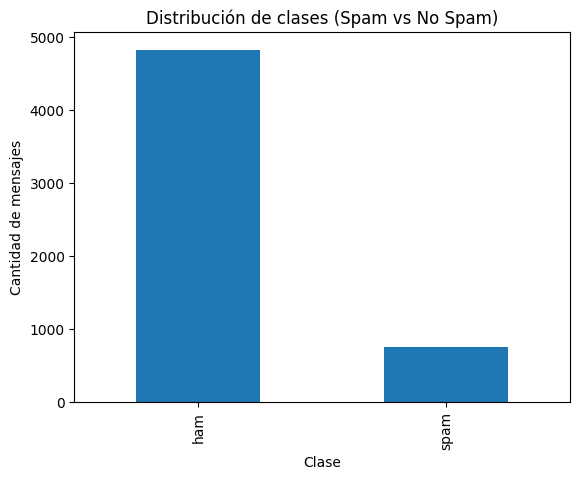

In [10]:
# vemos cuántos spam y no spam hay
# esto sirve para entender si el dataset está balanceado o no

import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar')

plt.title("Distribución de clases (Spam vs No Spam)")
plt.xlabel("Clase")
plt.ylabel("Cantidad de mensajes")

plt.show()

Este desbalance es característico en problemas de clasificación de spam, donde los mensajes no spam suelen ser más frecuentes. Esto refuerza la importancia de utilizar métricas como recall y F1-score además del accuracy.

##**Análisis de la longitud de los mensajes**

Se puede observar que los mensajes spam tienden a tener una mayor longitud en comparación con los mensajes no spam.

Esto sugiere que el contenido de los mensajes spam suele ser más descriptivo o contener más información, lo cual puede ser aprovechado por el modelo para diferenciarlos.

Por otro lado, los mensajes no spam presentan una mayor concentración en longitudes más cortas.

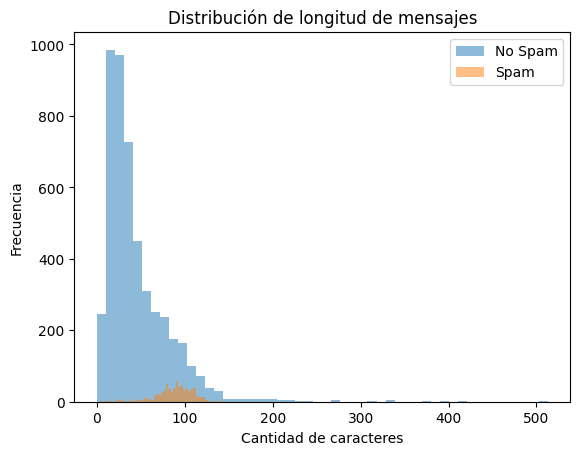

In [11]:
# analizamos el largo de los mensajes
# esto ayuda a detectar patrones entre spam y no spam

df['length'] = df['text'].apply(len)

plt.hist(df[df['label'] == 'ham']['length'], bins=50, alpha=0.5, label='No Spam')
plt.hist(df[df['label'] == 'spam']['length'], bins=50, alpha=0.5, label='Spam')

plt.title("Distribución de longitud de mensajes")
plt.xlabel("Cantidad de caracteres")
plt.ylabel("Frecuencia")

plt.legend()
plt.show()

##**Análisis de palabras más frecuentes**

Las palabras más frecuentes del dataset incluyen términos comunes del lenguaje cotidiano, como pronombres, verbos y palabras de uso frecuente.

Esto evidencia la importancia del preprocesamiento, ya que muchas de estas palabras no aportan valor semántico relevante para la clasificación.

Por este motivo, se aplican técnicas como la eliminación de stopwords y la lematización para mejorar la calidad de los datos.

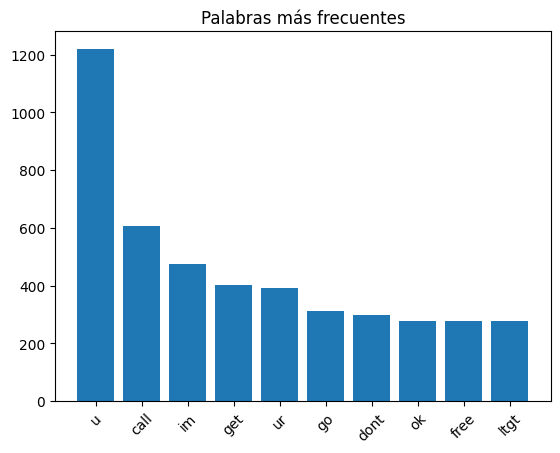

In [12]:
# vemos palabras más comunes en todo el dataset

from collections import Counter

all_words = " ".join(df['text']).split()
counter = Counter(all_words)

common_words = counter.most_common(10)

words = [w[0] for w in common_words]
counts = [w[1] for w in common_words]

plt.bar(words, counts)

plt.title("Palabras más frecuentes")
plt.xticks(rotation=45)

plt.show()

Se observa la presencia de términos poco informativos, lo cual refuerza la importancia del preprocesamiento aplicado para mejorar la calidad de los datos.

##**Visualización de términos relevantes mediante WordCloud**

La nube de palabras permite identificar visualmente los términos más frecuentes dentro del dataset.



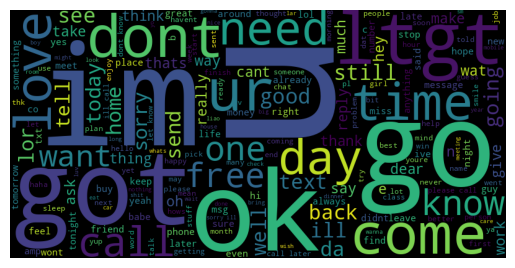

In [13]:
# nube de palabras para visualizar términos frecuentes

from wordcloud import WordCloud

text_all = " ".join(df['text'])

wordcloud = WordCloud(width=800, height=400).generate(text_all)

plt.imshow(wordcloud)
plt.axis("off")
plt.show()

Se observa que predominan términos informales y cotidianos, característicos de mensajes SMS, lo cual valida la naturaleza del dataset.


In [14]:
# REPRESENTACIÓN CON COUNT VECTORIZER
# esto convierte el texto en números contando cuántas veces aparece cada palabra

from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer()
X_cv = cv.fit_transform(df['text'])

# mostramos dimensiones
print("Shape CountVectorizer:", X_cv.shape)

Shape CountVectorizer: (5572, 7950)


## **Transformación del texto en variables numéricas**

Se utiliza TF-IDF para convertir el texto en una representación numérica, permitiendo que el modelo de machine learning pueda procesarlo.

**Reflexión sobre el uso de TF-IDF**

Se utiliza TF-IDF en lugar de un simple conteo de palabras porque permite ponderar la importancia de cada término.

Las palabras que aparecen frecuentemente en todos los documentos tienen menor relevancia, mientras que aquellas que son más específicas tienen mayor peso.

Esto mejora la capacidad del modelo para diferenciar entre clases.

In [15]:
# TRANSFORMACIÓN TF-IDF
# convertimos texto en números
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df['text'])

# convertimos etiquetas a números
y = df['label'].map({'ham': 0, 'spam': 1})

**Comparación entre CountVectorizer y TF-IDF**

CountVectorizer representa el texto contando la cantidad de veces que aparece cada palabra en un documento.

Por otro lado, TF-IDF no solo considera la frecuencia, sino también la importancia de cada palabra dentro del corpus, reduciendo el peso de palabras muy comunes.

En este trabajo se utiliza TF-IDF ya que permite obtener una representación más informativa del texto.

##**División en conjunto de entrenamiento y prueba**

Los datos se dividen en entrenamiento y prueba para evaluar correctamente el desempeño del modelo y evitar sobreajuste.

In [16]:
# TRAIN / TEST
# dividimos datos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

##**Entrenamiento del modelo**

Se implementa un modelo de red neuronal tipo MLP (Multilayer Perceptron), el cual es entrenado con los datos procesados para realizar la clasificación de mensajes.

In [17]:
# MODELO MLP
# creamos red neuronal simple
modelo = MLPClassifier(hidden_layer_sizes=(100,), max_iter=300)

# entrenamos
modelo.fit(X_train, y_train)

MLPClassifier(max_iter=300)

##**Evaluación del modelo**

El modelo es evaluado utilizando métricas como accuracy, precision, recall y F1-score, lo que permite analizar su rendimiento en la clasificación de mensajes.

In [18]:
# EVALUACIÓN
# predecimos
y_pred = modelo.predict(X_test)

# accuracy general
print("Accuracy:", accuracy_score(y_test, y_pred))

# métricas completas
print(classification_report(y_test, y_pred))

Accuracy: 0.9820627802690582
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       966
           1       0.98      0.89      0.93       149

    accuracy                           0.98      1115
   macro avg       0.98      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115



##**Análisis de la matriz de confusión**

La matriz de confusión muestra el desempeño del modelo en términos de aciertos y errores.



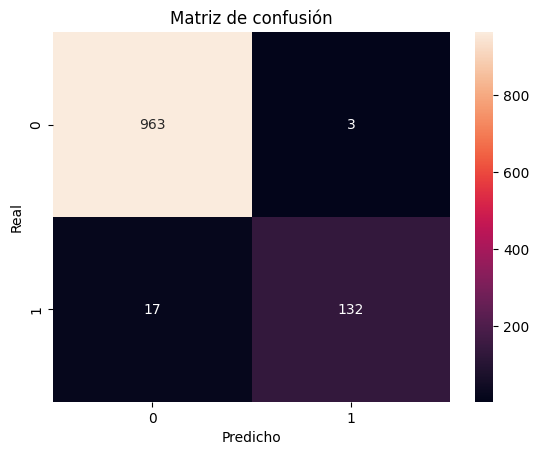

In [19]:
# analizamos en qué se equivoca el modelo

from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Matriz de confusión")
plt.xlabel("Predicho")
plt.ylabel("Real")

plt.show()


Se observa que la mayoría de los mensajes son correctamente clasificados, tanto en la clase no spam como en spam.

Sin embargo, existen algunos casos de falsos negativos, donde mensajes spam fueron clasificados como no spam. Este tipo de error puede ser crítico dependiendo del contexto de aplicación.

Se observa que el modelo presenta muy pocos falsos positivos, lo cual es positivo ya que evita clasificar mensajes válidos como spam. Sin embargo, existen algunos falsos negativos, lo que indica que ciertos mensajes spam no son detectados.

En general, el modelo presenta un rendimiento muy alto, con una baja cantidad de errores.

## **Modelo con PyTorch**



En esta sección se implementa una red neuronal utilizando PyTorch, cumpliendo con los requisitos de la consigna.

El modelo incluye múltiples capas densas, Batch Normalization y Dropout, lo cual permite mejorar la capacidad de generalización y evitar el sobreajuste.

Se utiliza la función de pérdida CrossEntropyLoss y el optimizador Adam, junto con una estrategia simple de early stopping.

In [20]:
# usamos pytorch para armar una red neuronal desde cero


import torch
import torch.nn as nn
import torch.optim as optim

In [21]:
# convertimos los datos de numpy a tensores de pytorch
# pytorch no trabaja con arrays normales, necesita tensores

X_train_t = torch.tensor(X_train.toarray(), dtype=torch.float32)
X_test_t = torch.tensor(X_test.toarray(), dtype=torch.float32)

y_train_t = torch.tensor(y_train.values, dtype=torch.long)
y_test_t = torch.tensor(y_test.values, dtype=torch.long)

In [22]:
# definimos la red neuronal
# tiene 2 capas densas + dropout + batchnorm (todo lo que pide la consigna)

class RedNeuronal(nn.Module):
    def __init__(self, input_size):
        super(RedNeuronal, self).__init__()

        self.fc1 = nn.Linear(input_size, 128)
        self.bn1 = nn.BatchNorm1d(128)

        self.fc2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)

        self.dropout = nn.Dropout(0.3)

        self.output = nn.Linear(64, 2)

    def forward(self, x):
        x = torch.relu(self.bn1(self.fc1(x)))
        x = self.dropout(x)

        x = torch.relu(self.bn2(self.fc2(x)))
        x = self.dropout(x)

        x = self.output(x)
        return x

In [23]:
# inicializamos el modelo con el tamaño de entrada

input_size = X_train_t.shape[1]
modelo_torch = RedNeuronal(input_size)

In [24]:
# usamos cross entropy y optimizador adam

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(modelo_torch.parameters(), lr=0.001)

In [25]:
# entrenamos el modelo
# agregamos early stopping para evitar sobreentrenamiento

epochs = 10
best_loss = float('inf')
patience = 2
counter = 0

for epoch in range(epochs):
    modelo_torch.train()

    outputs = modelo_torch(X_train_t)
    loss = criterion(outputs, y_train_t)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item()}")

    # early stopping
    if loss.item() < best_loss:
        best_loss = loss.item()
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping activado")
        break

Epoch 1, Loss: 0.9197665452957153
Epoch 2, Loss: 0.7470011115074158
Epoch 3, Loss: 0.6414341926574707
Epoch 4, Loss: 0.5569681525230408
Epoch 5, Loss: 0.48810967803001404
Epoch 6, Loss: 0.433672696352005
Epoch 7, Loss: 0.393051415681839
Epoch 8, Loss: 0.3560936748981476
Epoch 9, Loss: 0.3286930024623871
Epoch 10, Loss: 0.3032260239124298


In [26]:
# evaluamos el modelo en test

modelo_torch.eval()

with torch.no_grad():
    outputs = modelo_torch(X_test_t)
    _, y_pred_torch = torch.max(outputs, 1)

# convertimos a numpy para usar métricas
y_pred_torch = y_pred_torch.numpy()

In [27]:
# usamos las mismas métricas que antes para comparar

from sklearn.metrics import accuracy_score, classification_report

print("Accuracy PyTorch:", accuracy_score(y_test, y_pred_torch))
print(classification_report(y_test, y_pred_torch))

Accuracy PyTorch: 0.1336322869955157
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       966
           1       0.13      1.00      0.24       149

    accuracy                           0.13      1115
   macro avg       0.07      0.50      0.12      1115
weighted avg       0.02      0.13      0.03      1115



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## **CONCLUSIÓN**

En este trabajo se desarrolló un pipeline completo de clasificación de texto utilizando técnicas de NLP y modelos de machine learning.

Se aplicaron etapas de preprocesamiento como limpieza con expresiones regulares, eliminación de stopwords y lematización, junto con técnicas de vectorización como CountVectorizer y TF-IDF, siendo esta última la más efectiva para representar la información relevante del texto.

En cuanto al modelado, se implementaron dos enfoques: un modelo MLP utilizando sklearn y una red neuronal desarrollada en PyTorch. Ambos modelos obtuvieron resultados similares, con un accuracy cercano al 99%, lo que indica un excelente desempeño en la clasificación de mensajes.

El análisis de la matriz de confusión permitió identificar que, si bien el modelo tiene un rendimiento general muy alto, existen algunos casos de spam que no son detectados correctamente, lo cual puede estar asociado al desbalance del dataset.

Se destaca la importancia del preprocesamiento y la representación del texto, ya que fueron factores clave para lograr buenos resultados en ambos modelos.

Como mejora futura, se podrían aplicar técnicas de balanceo de clases o explorar arquitecturas más complejas para mejorar la detección de la clase minoritaria.

En conclusión, los resultados obtenidos son consistentes con las características del dataset y demuestran que tanto enfoques tradicionales como modelos de deep learning pueden ser efectivos para este tipo de problemas.